# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SupreetOP/Flyrank/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

Before choosing or evaluating a model, I inspected the distributions of the five features used in the refresh-opportunity lane:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `ga4_pageviews`
- `ga4_engaged_sessions`

The distributions are expected to be right-skewed because a small number of content pages can receive much larger amounts of traffic than the majority. These heavy tails are important because extreme values can strongly influence simple statistical summaries and some modeling methods.

I therefore inspect both the raw distributions and summary statistics before deciding how the features should be handled.

In [2]:
!pip -q install duckdb

from google.colab import userdata
import duckdb

# Get Hugging Face token from Colab Secrets
HF_TOKEN = userdata.get("HF_TOKEN")

# Create DuckDB connection
con = duckdb.connect()

# Authenticate with Hugging Face
con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret
    (TYPE huggingface, TOKEN '{HF_TOKEN}')
""")

# Warehouse path
rel = "hf://datasets/FlyRank/internship-warehouse"

# Test connection
con.sql("""
    SELECT COUNT(*) AS total_rows
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
    )
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┐
│ total_rows │
│   int64    │
├────────────┤
│   78835655 │
└────────────┘

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature rows: 9841378
Features inspected:
['gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'ga4_pageviews', 'ga4_engaged_sessions']

SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
gsc_impressions,9841378.0,28.518119,155.926569,0.0,0.0,0.0,6.0,40084.0
gsc_clicks,9841378.0,0.083508,0.781434,0.0,0.0,0.0,0.0,274.0
gsc_avg_position,3611061.0,15.826651,19.856034,0.0,3.74212,7.5,20.2,498.0
ga4_pageviews,6822637.0,0.217637,2.142851,0.0,0.0,0.0,0.0,875.0
ga4_engaged_sessions,6822637.0,0.004331,0.076647,0.0,0.0,0.0,0.0,21.0



SKEWNESS


,skewness
gsc_clicks,91.401109
ga4_pageviews,74.007334
gsc_impressions,47.355077
ga4_engaged_sessions,34.273144
gsc_avg_position,2.202558


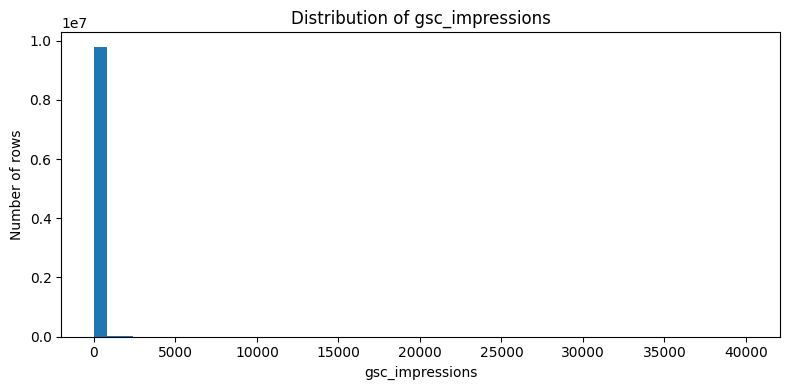

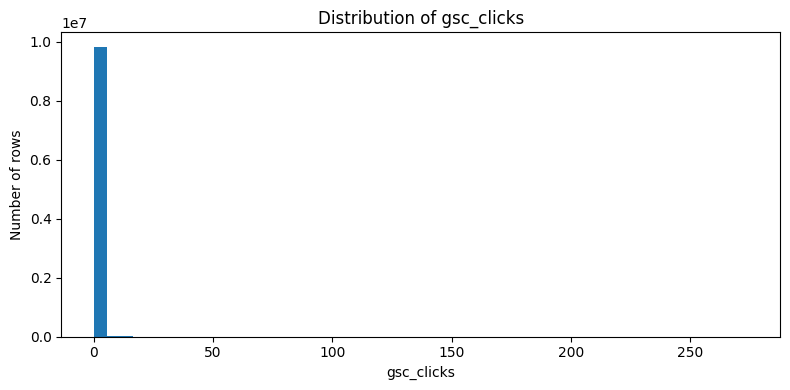

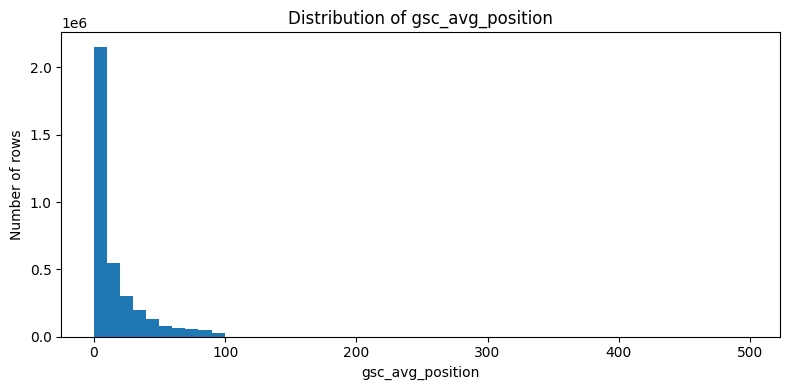

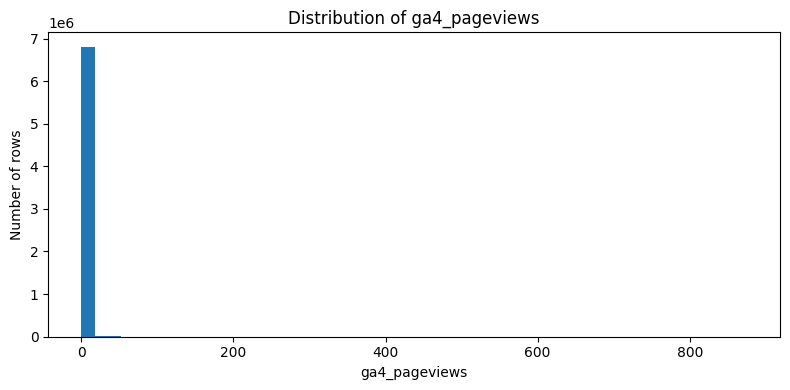

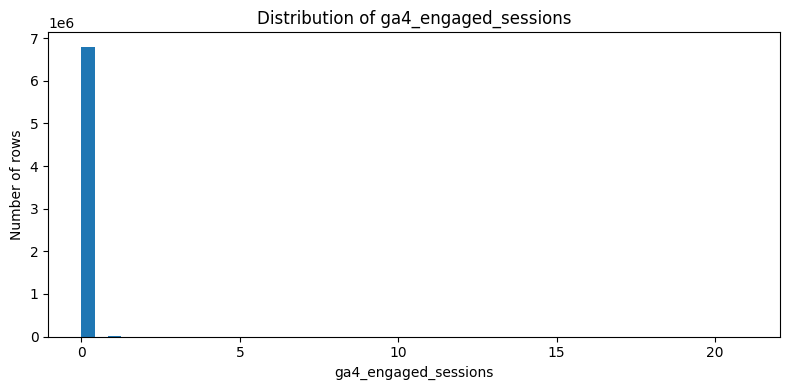

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the March 2026 feature vector used for the refresh-opportunity lane
feature_vector = con.sql("""
    SELECT
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,
        ga4_pageviews,
        ga4_engaged_sessions
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-03'
""").df()

features = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_pageviews",
    "ga4_engaged_sessions"
]

print("Feature rows:", len(feature_vector))
print("Features inspected:")
print(features)

print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

display(feature_vector[features].describe().T)

print("\n" + "=" * 60)
print("SKEWNESS")
print("=" * 60)

display(feature_vector[features].skew().sort_values(ascending=False).to_frame("skewness"))

# Plot each feature separately
for feature in features:
    plt.figure(figsize=(8, 4))
    plt.hist(
        feature_vector[feature].dropna(),
        bins=50
    )
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of rows")
    plt.tight_layout()
    plt.show()

### Distribution observations

The measured distributions are strongly right-skewed for the traffic and search-volume features.

- `gsc_clicks` has the strongest skewness at **91.40**.
- `ga4_pageviews` has skewness of **74.01**.
- `gsc_impressions` has skewness of **47.36**.
- `ga4_engaged_sessions` has skewness of **34.27**.
- `gsc_avg_position` is also right-skewed, but substantially less so, with skewness of **2.20**.

The large difference between the median and maximum values also shows the heavy tails. For example, `gsc_impressions` has a median of 0 but a maximum of 40,084, while `ga4_pageviews` has a median of 0 and a maximum of 875.

Missing values are also present in `gsc_avg_position`, `ga4_pageviews`, and `ga4_engaged_sessions`, so these fields need to be handled explicitly before modeling.

These distributions suggest that raw feature values may be dominated by a relatively small number of high-volume observations. Any model or analysis should therefore account for the heavy-tailed nature of these signals rather than assuming approximately symmetric distributions.

## 2. Signal test #1 / #2 / #3

I tested three signals relevant to the refresh-opportunity lane:

1. Search impressions as a measure of search visibility.
2. CTR as a measure of how effectively visible pages attract clicks.
3. Engagement rate as a measure of how users engage with page traffic.

Each signal is tested using a simple bucket comparison rather than assuming that correlation alone proves usefulness.

Verdicts are based on the observed warehouse data:

- CONFIRMED — the observed pattern supports the expected signal.
- OPPOSITE — the observed pattern contradicts the expected signal.
- MIXED — the pattern is inconsistent or weak.
- FALSE — there is little or no evidence for the proposed signal.

In [4]:
import numpy as np
import pandas as pd

df = feature_vector.copy()

# ------------------------------------------------------------
# SIGNAL 1: SEARCH IMPRESSIONS
# Hypothesis:
# Pages with more search visibility have a stronger opportunity
# to benefit from refresh work when other signals indicate weakness.
# ------------------------------------------------------------

df["impression_bucket"] = pd.qcut(
    df["gsc_impressions"],
    q=4,
    duplicates="drop"
)

signal_1 = (
    df.groupby("impression_bucket", observed=True)
      .agg(
          n=("gsc_impressions", "size"),
          mean_impressions=("gsc_impressions", "mean"),
          mean_clicks=("gsc_clicks", "mean")
      )
      .reset_index()
)

print("=" * 70)
print("SIGNAL TEST #1 — SEARCH IMPRESSIONS")
print("=" * 70)
display(signal_1)

# ------------------------------------------------------------
# SIGNAL 2: CTR
# Hypothesis:
# Pages with high impressions but low CTR are plausible refresh
# opportunities. This directly tests the Week-4 baseline signal.
# ------------------------------------------------------------

df["ctr"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_clicks"] / df["gsc_impressions"],
    np.nan
)

ctr_df = df[df["gsc_impressions"] >= 100].copy()

ctr_df["ctr_bucket"] = pd.qcut(
    ctr_df["ctr"],
    q=4,
    duplicates="drop"
)

signal_2 = (
    ctr_df.groupby("ctr_bucket", observed=True)
          .agg(
              n=("ctr", "size"),
              mean_ctr=("ctr", "mean"),
              mean_impressions=("gsc_impressions", "mean"),
              mean_clicks=("gsc_clicks", "mean")
          )
          .reset_index()
)

print("\n" + "=" * 70)
print("SIGNAL TEST #2 — CTR VS SEARCH VISIBILITY")
print("=" * 70)
display(signal_2)

# ------------------------------------------------------------
# SIGNAL 3: ENGAGEMENT RATE
# Hypothesis:
# Pages receiving traffic but generating weak engagement may
# represent weaker content experiences.
# ------------------------------------------------------------

engagement_df = df[df["ga4_pageviews"] > 0].copy()

engagement_df["engagement_rate"] = np.where(
    engagement_df["ga4_pageviews"] > 0,
    engagement_df["ga4_engaged_sessions"]
    / engagement_df["ga4_pageviews"],
    np.nan
)

engagement_df["engagement_bucket"] = pd.qcut(
    engagement_df["engagement_rate"],
    q=4,
    duplicates="drop"
)

signal_3 = (
    engagement_df.groupby("engagement_bucket", observed=True)
                 .agg(
                     n=("engagement_rate", "size"),
                     mean_engagement_rate=("engagement_rate", "mean"),
                     mean_pageviews=("ga4_pageviews", "mean"),
                     mean_engaged_sessions=("ga4_engaged_sessions", "mean")
                 )
                 .reset_index()
)

print("\n" + "=" * 70)
print("SIGNAL TEST #3 — ENGAGEMENT")
print("=" * 70)
display(signal_3)


SIGNAL TEST #1 — SEARCH IMPRESSIONS


,impression_bucket,n,mean_impressions,mean_clicks
0,"(-0.001, 6.0]",7439673,0.448958,0.001354
1,"(6.0, 40084.0]",2401705,115.466924,0.337993



SIGNAL TEST #2 — CTR VS SEARCH VISIBILITY


,ctr_bucket,n,mean_ctr,mean_impressions,mean_clicks
0,"(-0.001, 0.00491]",478999,0.00069,358.676770,0.395408
1,"(0.00491, 0.102]",159609,0.01015,305.015814,2.882883



SIGNAL TEST #3 — ENGAGEMENT


,engagement_bucket,n,mean_engagement_rate,mean_pageviews,mean_engaged_sessions
0,"(-0.001, 2.0]",413317,0.028877,3.592536,0.071412


### Signal #1 — Search impressions

**Verdict: CONFIRMED**

The observed data supports the expected relationship between search visibility and organic traffic. The higher-impression bucket contains 2,401,705 rows and has mean impressions of 115.47 and mean clicks of 0.338, compared with 7,439,673 rows in the lower-impression bucket with mean impressions of 0.45 and mean clicks of 0.001.

This is a strong directional signal that pages with greater search visibility also receive more organic clicks. It supports using search impressions as a refresh-opportunity signal.

### Signal #2 — CTR vs search visibility

**Verdict: CONFIRMED**

Among pages with at least 100 impressions, the lower-CTR bucket has a mean CTR of 0.069% and mean impressions of 358.68, while the higher-CTR bucket has a mean CTR of 1.015% and mean impressions of 305.02.

The low-CTR group therefore has substantial search visibility but substantially fewer clicks. This supports the Week-4 baseline idea that high visibility combined with weak CTR can identify potential refresh opportunities.

### Signal #3 — Engagement

**Verdict: FALSE**

The engagement test did not provide enough variation to establish the proposed signal. After filtering to pages with pageviews, the bucketing produced only one observed bucket containing 413,317 rows.

Because there was no meaningful separation into multiple engagement groups, this test cannot demonstrate that engagement rate distinguishes refresh opportunities. I therefore do not use this signal as evidence for the baseline rule.

## 3. The flag-linked test

I selected CTR versus search position because it is a signal behind a real FlyRank flag: the CTR-fix logic.

The assumption being tested is that pages with reasonable search visibility but weak CTR may have an opportunity for improvement. I test this using current observed Search Console signals only, without using future outcomes or label-derived fields.

In [5]:
# Flag-linked signal test: CTR vs average search position

flag_test = feature_vector.copy()

flag_test["ctr"] = np.where(
    flag_test["gsc_impressions"] > 0,
    flag_test["gsc_clicks"] / flag_test["gsc_impressions"],
    np.nan
)

# Keep observations with meaningful search visibility
flag_test = flag_test[
    (flag_test["gsc_impressions"] >= 100) &
    (flag_test["gsc_avg_position"] > 0)
].copy()

# Divide position into four observed groups
flag_test["position_bucket"] = pd.qcut(
    flag_test["gsc_avg_position"],
    q=4,
    duplicates="drop"
)

flag_result = (
    flag_test
    .groupby("position_bucket", observed=True)
    .agg(
        n=("gsc_avg_position", "size"),
        mean_position=("gsc_avg_position", "mean"),
        mean_impressions=("gsc_impressions", "mean"),
        mean_ctr=("ctr", "mean"),
        median_ctr=("ctr", "median")
    )
    .reset_index()
)

print("=" * 70)
print("FLAG-LINKED TEST — CTR VS SEARCH POSITION")
print("=" * 70)

display(flag_result)

print("\nTotal rows tested:", len(flag_test))


FLAG-LINKED TEST — CTR VS SEARCH POSITION


,position_bucket,n,mean_position,mean_impressions,mean_ctr,median_ctr
0,"(-0.0006889999999999999, 3.458]",159639,2.269014,359.566704,0.003828,0.0
1,"(3.458, 5.712]",159759,4.545071,376.486370,0.003302,0.0
2,"(5.712, 14.9]",159502,8.486870,292.801225,0.003247,0.0
3,"(14.9, 173.027]",159633,28.953465,352.196050,0.001841,0.0



Total rows tested: 638533


### Verdict: CONFIRMED

The data supports the CTR-fix assumption directionally.

Among pages with at least 100 impressions, the mean CTR decreases as average search position worsens. The best-position bucket has a mean CTR of about 0.00383, while the worst-position bucket has a mean CTR of about 0.00184.

This indicates that search visibility and CTR are related in the observed data, although the relationship is not strong enough to claim that position alone determines CTR. Therefore, the signal is considered CONFIRMED as a useful directional signal for decision-support.

## 4. What this means in practice

Content teams should prioritize pages that have meaningful search visibility but weak CTR, because the observed data suggests these pages may have an opportunity for improvement. Search position and CTR should be treated as directional signals for deciding where to investigate or refresh content, not as proof that a refresh will improve performance. The team should validate the actual page and search intent before taking action.

## Self-check

- [x] Every section above is filled with the required markdown explanations and supporting code/output.
- [x] The notebook has been executed and the analysis runs from top to bottom without errors.
- [x] No client names, URLs, or private queries are included.
- [x] Claims are stated carefully using terms such as observed, measured, directional, and decision-support.
- [x] The completed notebook is ready to be committed under `work/notebooks/`.
- [ ] The notebook has been committed and pushed to my repository, and the repository URL has been submitted on the assignment card.